In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
import glob
import os

from lmfit import Model
from lmfit.models import SineModel, ConstantModel, GaussianModel

In [2]:
FILENAME = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
            '/Unmounted_device_mk_3/2026_04_15/pair_generation/correlation_01.txt')
FITTING = True  # add a fit
integration_time = 2 * 60  # seconds


def g_2_exp_bg(x, x0, bg, amplitude, T_1, T_2):
    """Another fitting function for cavity decay.

    Fit as two exponentials with a constant background offset.

    Args:
        x (np.ndarray): time-domain x-values
        x0 (float): center of coincidence peak
        bg (float): value of accidental coincidences
        amplitude (float): amplitude of coincidence peak
        T_1 (float): decay constant for right (positive) side of peak
        T_2 (float): decay constant for left (negative) side of peak

    Return:
        np.ndarray: coincidence histogram
    """
    right_decay = np.heaviside(x-x0, 0.5) * np.exp(-(x-x0) / T_1)
    left_decay = np.heaviside(x0-x, 0.5) * np.exp(-(x0-x) / T_2)
    bg_arr = bg * np.ones_like(x)
    return (amplitude * right_decay) + (amplitude * left_decay) + bg_arr


# NOTE: first line of csv needs extra tab added
# otherwise the columns will not be read properly
df = pd.read_csv(FILENAME, sep='\t')
coincidence = df['Counts'] / integration_time
time_coincidence = df["Time(ps)"]  # unit: ps
time_coincidence *= 1e-3  # unit: ns
time_diff = time_coincidence[1] - time_coincidence[0]  # spacing of histogram

# fitting
model = Model(g_2_exp_bg)

x0_guess = 25
bg_guess = 1
amplitude_guess = 10
T_1_guess = 1
T_2_guess = 1

res_coincidence = model.fit(coincidence, x=time_coincidence,
                x0=x0_guess,
                bg=bg_guess,
                amplitude=amplitude_guess,
                T_1=T_1_guess,
                T_2=T_2_guess)
print(res_coincidence.fit_report())

[[Model]]
    Model(g_2_exp_bg)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 43
    # data points      = 10000
    # variables        = 5
    chi-square         = 218.561025
    reduced chi-square = 0.02186704
    Akaike info crit   = -38222.7510
    Bayesian info crit = -38186.6993
    R-squared          = 0.97336387
[[Variables]]
    x0:         25.1498296 +/- 0.00246722 (0.01%) (init = 25)
    bg:         2.33424398 +/- 0.00148503 (0.06%) (init = 1)
    amplitude:  27.5955819 +/- 0.06458267 (0.23%) (init = 10)
    T_1:        1.09164950 +/- 0.00502457 (0.46%) (init = 1)
    T_2:        1.01803018 +/- 0.00485191 (0.48%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(amplitude, T_1) = -0.5092
    C(x0, T_2)        = +0.5092
    C(amplitude, T_2) = -0.4918
    C(x0, T_1)        = -0.4918


     Time(ps)  Counts  Unnamed: 2
0      -50000      45         NaN
1      -49900      34         NaN
2      -49800      47         NaN
3      -49700      42         NaN
4      -49600      45         NaN
..        ...     ...         ...
995     49500      51         NaN
996     49600      56         NaN
997     49700      45         NaN
998     49800      44         NaN
999     49900      50         NaN

[1000 rows x 3 columns]
Center bin: 389
Center time: -11.10 ns
384 , 394
coincidence counts: 9114
bg counts 415.025
pairs: 8698.975


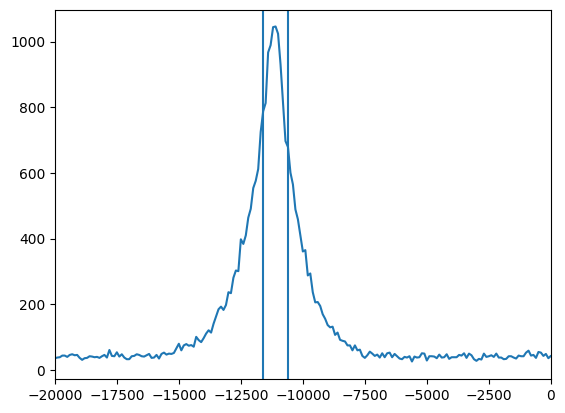

In [5]:
DATA_DIR_EFF = '/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators/Unmounted_device_mk_3/2026_06_09'
num_bins = 10
num_bins_exclude_bg = 200
integration_time = 2 * 60

data_df = pd.read_csv(DATA_DIR_EFF+'/file_1_pairs.txt',sep='\t')
print(data_df)
center_bin = np.argmax(data_df['Counts'])
print(f'Center bin: {center_bin}')
print(f'Center time: {data_df["Time(ps)"][center_bin] * 1e-3:.2f} ns')

# fitting
coincidence_model = Model(g_2_exp_bg)
coincidence = data_df['Counts'] / integration_time  # convert to counts/s
time_coincidence = data_df['Time(ps)'] * 1e-3  # convert to ns
x0_guess = 25
bg_guess = 1
amplitude_guess = np.max(coincidence)
T_1_guess = 1
T_2_guess = 1


# extract coincidences and CAR
idx_start = center_bin - num_bins // 2
idx_end = center_bin + num_bins // 2
print(idx_start,",",idx_end)
idx_bg_exclude_start = center_bin - num_bins_exclude_bg // 2
idx_bg_exclude_end = center_bin + num_bins_exclude_bg // 2
coincidences = []
car = []
bg_vals = []

coincidences_bg_subtract = []

f_vals = []

counts = np.sum(data_df['Counts'][idx_start:idx_end])
coincidences.append(counts)

num_bg_bins = len(data_df['Counts']) - (idx_bg_exclude_end-idx_bg_exclude_start)
bg = np.sum(data_df['Counts'][:idx_bg_exclude_start]) + np.sum(data_df['Counts'][idx_bg_exclude_end:])
bg /= num_bg_bins
print("coincidence counts:",counts)

bg_vals.append(bg)
bg_center = bg*(idx_end-idx_start)
print("bg counts",bg_center)
# print(f'Background: {bg:.2f}')
car.append((counts - bg_center) / bg_center)

coinc_bg_subtract = counts-(idx_end-idx_start)*bg
tot_bg_subtract = np.sum(data_df['Counts'][idx_bg_exclude_start:idx_bg_exclude_end])-(idx_bg_exclude_end-idx_bg_exclude_start)*bg#np.sum(data_df['Counts'])-len(data_df['Counts'])*bg
f_vals.append(coinc_bg_subtract/tot_bg_subtract)
coincidences_bg_subtract.append(coinc_bg_subtract)


plt.figure()
plt.plot(data_df['Time(ps)'],data_df['Counts'])
plt.axvline(data_df['Time(ps)'][idx_start])
plt.axvline(data_df['Time(ps)'][idx_end])
plt.xlim(-20000,0)

print("pairs:",counts-bg_center)
pair_counts = counts-bg_center

In [10]:
data_df_singles = pd.read_csv(DATA_DIR_EFF + '/file_1_singles.txt', sep='\t')
counts_per_sec_1 = np.mean(data_df_singles['counts(1/s)'])
counts_per_sec_2 = np.mean(data_df_singles['counts(1/s).1'])
print(f"singles counts (1/s): {counts_per_sec_1} , {counts_per_sec_2}")
eff_1 = pair_counts / integration_time / counts_per_sec_2
eff_2 = pair_counts / integration_time / counts_per_sec_1
print(f"channel efficiencies (1,2): {eff_1} , {eff_2}")

singles counts (1/s): 45472.3 , 71842.0
channel efficiencies (1,2): 0.0010090400926106365 , 0.0015941893929564447


In [13]:
DATA_DIR = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
            '/Unmounted_device_mk_3/2026_04_15/pair_generation')
POWER_FILE = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
              '/Unmounted_device_mk_3/2026_04_15/pair_generation/correlation_power.csv')
file_fmt = 'correlation_{:02}.txt'
file_num_center_bin = 1
num_bins = 10  # number of bins to use for coincidence calculation
num_bins_exclude_bg = 200
integration_time = 2 * 60  # seconds

# power parameters
power_99 = 5320  # power measured at 99% arm of beamsplitter (in uW)
power_1 = 54.3  # power measured at 1% arm of beamsplitter (in uW)
power_ratio = power_99 / power_1

# efficiency parameters
snspd_52_efficiency = 0.4532 * 0.7274   # includes filter loss and detector inefficiency
snspd_48_efficiency = 0.4790 * 0.9260


# fitting function versus power
def quadratic(x, a):
    return a * (x ** 2)


# read power file
power_df = pd.read_csv(POWER_FILE)
file_numbers = power_df['File']

# get on-chip power
measured_bs_power = power_df['Beamsplitter Power (uW)']
input_power = measured_bs_power * power_ratio
output_power = power_df['Output Power (uW)']
total_efficiency = output_power / input_power
on_chip_power = np.sqrt(total_efficiency) * input_power
# print(np.sqrt(total_efficiency))
print(on_chip_power)

# loop over files
data_dfs = []
center_bin = 0
for i, file_num in enumerate(file_numbers):
    file_path = os.path.join(DATA_DIR, file_fmt.format(file_num))
    data_df = pd.read_csv(file_path, sep='\t')
    data_dfs.append(data_df)

    if file_num == file_num_center_bin:
        center_bin = np.argmax(data_df['Counts'])
        print(f'Center bin: {center_bin}')
        print(f'Center time: {data_df["Time(ps)"][center_bin] * 1e-3:.2f} ns')

    if file_num == 1:
        print(on_chip_power[i])
        # fitting
        coincidence_model = Model(g_2_exp_bg)
        coincidence = data_df['Counts'] / integration_time  # convert to counts/s
        coincidence_on_chip = coincidence / (total_efficiency[i] * snspd_48_efficiency * snspd_52_efficiency)
        time_coincidence = data_df['Time(ps)'] * 1e-3  # convert to ns
        x0_guess = 25
        bg_guess = 1
        amplitude_guess = np.max(coincidence_on_chip)
        T_1_guess = 1
        T_2_guess = 1
        res_coincidence_on_chip = coincidence_model.fit(coincidence_on_chip, x=time_coincidence,
                                                x0=x0_guess,
                                                bg=bg_guess,
                                                amplitude=amplitude_guess,
                                                T_1=T_1_guess,
                                                T_2=T_2_guess)
        print(res_coincidence_on_chip.fit_report())
        time_coincidence -= res_coincidence.params['x0'].value

# extract coincidences and CAR
idx_start = center_bin - num_bins // 2
idx_end = center_bin + num_bins // 2 + 1
print(idx_start,",",idx_end)
idx_bg_exclude_start = center_bin - num_bins_exclude_bg // 2
idx_bg_exclude_end = center_bin + num_bins_exclude_bg // 2 + 1
coincidences = []
car = []
bg_vals = []

coincidences_bg_subtract = []

f_vals = []
for data_df in data_dfs:
    counts = np.sum(data_df['Counts'][idx_start:idx_end])
    coincidences.append(counts)

    num_bg_bins = len(data_df['Counts']) - (idx_bg_exclude_end-idx_bg_exclude_start)
    bg = np.sum(data_df['Counts'][:idx_bg_exclude_start]) + np.sum(data_df['Counts'][idx_bg_exclude_end:])
    bg /= num_bg_bins
    print("coincidence counts:",counts)
    print("bg counts",bg)
    bg_vals.append(bg)
    bg_center = bg*(idx_end-idx_start)
    # print(f'Background: {bg:.2f}')
    car.append((counts - bg_center) / bg_center)

    coinc_bg_subtract = counts-(idx_end-idx_start)*bg
    tot_bg_subtract = np.sum(data_df['Counts'][idx_bg_exclude_start:idx_bg_exclude_end])-(idx_bg_exclude_end-idx_bg_exclude_start)*bg#np.sum(data_df['Counts'])-len(data_df['Counts'])*bg
    f_vals.append(coinc_bg_subtract/tot_bg_subtract)
    coincidences_bg_subtract.append(coinc_bg_subtract)
    #plt.figure()
    #plt.plot(data_df['Time(ps)'][idx_bg_exclude_start:idx_bg_exclude_end],data_df['Counts'][idx_bg_exclude_start:idx_bg_exclude_end])
    #plt.plot(data_df['Time(ps)'][idx_bg_exclude_start:idx_bg_exclude_end],bg*np.ones_like(data_df['Time(ps)'][idx_bg_exclude_start:idx_bg_exclude_end]))

# fit coincidences
model = Model(quadratic)
coincidence_rate = np.array(coincidences) / integration_time
bg_rate = np.array(bg_vals) / integration_time * (idx_end-idx_start)
res_power = model.fit(coincidence_rate, x=on_chip_power,
                      a=0.5)
print(res_power.fit_report())
coincidences_bg_subtract = np.array(coincidences_bg_subtract) / integration_time

# fit coincidence rate on-chip
bg_vals_on_chip = bg_rate / (total_efficiency * snspd_48_efficiency * snspd_52_efficiency)
coincidence_rate_on_chip = coincidence_rate / (total_efficiency * snspd_48_efficiency * snspd_52_efficiency)
coincidence_rate_on_chip_bg_sub = np.array(coincidences_bg_subtract)/(total_efficiency * snspd_48_efficiency * snspd_52_efficiency) / integration_time
res_on_chip = model.fit(coincidence_rate_on_chip, x=on_chip_power/1e3, # convert to mW
                        a=3e5)

print(res_on_chip.fit_report())

# fit background-subtracted
res_on_chip_bg_sub = model.fit(coincidence_rate_on_chip_bg_sub, x=on_chip_power/1e3, # convert to mW
                        a=3e5)
print(res_on_chip_bg_sub.fit_report())

0    1129.470092
1    1024.605423
2     910.125760
3     801.301947
4     687.365162
5     565.400411
6     455.221419
7     341.272400
8     222.861055
9     111.546966
dtype: float64
Center bin: 5252
Center time: 25.20 ns
1129.4700920193125
[[Model]]
    Model(g_2_exp_bg)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 31
    # data points      = 10000
    # variables        = 5
    chi-square         = 2.3708e+09
    reduced chi-square = 237196.808
    Akaike info crit   = 123771.454
    Bayesian info crit = 123807.505
    R-squared          = 0.97224611
[[Variables]]
    x0:         25.0944207 +/- 0.00258976 (0.01%) (init = 25)
    bg:         7531.05711 +/- 4.89113192 (0.06%) (init = 1)
    amplitude:  88510.6260 +/- 213.464336 (0.24%) (init = 88944.14)
    T_1:        1.15262181 +/- 0.00509942 (0.44%) (init = 1)
    T_2:        0.97232061 +/- 0.00509827 (0.52%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(x0, T_2)        = +

In [14]:
print(bg_vals_on_chip)
print(coincidence_rate_on_chip)

0    82905.677353
1    44532.592485
2    42073.985399
3    23642.877979
4    14403.400679
5     6871.192352
6     4337.022908
7     1627.950477
8      683.026395
9      123.109002
dtype: float64
0    842468.784642
1    551807.395233
2    539073.459816
3    359702.023101
4    260616.320415
5    157582.845844
6    119641.548894
7     57994.576324
8     29709.799026
9      6979.605427
dtype: float64


In [15]:
eff = 2.45e-3
t_bin = time_diff * 1e-9 * (num_bins+1)
# c_p = 550000
c_d = 5 / 2.4e-3  # counts/s dark counts on chip
eff_guess = np.sqrt(np.mean(total_efficiency * snspd_48_efficiency * snspd_52_efficiency))
print(c_d)
f = 1
spec_frac = 1

2083.3333333333335


In [16]:
def true_pairs(power, c_p):
    lambda_p = c_p * t_bin*np.square(power)  # mean pair number on chip
    return spec_frac*lambda_p / t_bin * np.square(eff)


def car_model(power, c_r):
    lambda_d = c_d*t_bin
    lambda_p = c_p*t_bin*np.square(power) #mean pair number on chip
    lambda_r = c_r * t_bin * power #mean raman photon number on chip
    #return (f*lambda_p+np.square(lambda_p+lambda_r+lambda_d))/np.square(lambda_p+lambda_r+lambda_d)
    return (spec_frac*lambda_p)/np.square(f*lambda_p+lambda_r+lambda_d)


def bg_model(power):
    lambda_d = c_d * t_bin
    lambda_p = c_p * t_bin * np.square(power) #mean pair number on chip
    lambda_r = c_r * t_bin * power #mean raman photon number on chip
    return np.square(lambda_d+f*lambda_p+lambda_r)/t_bin*np.square(eff)


def raman_raman(power):
    lambda_p = c_p * t_bin * np.square(power) #mean pair number on chip
    lambda_r = c_r * t_bin * power #mean raman photon number on chip
    return np.square(lambda_r)/t_bin*np.square(eff)


def uncorrelated_pairs(power):
    lambda_p = c_p * t_bin * np.square(power)  # mean pair number on chip
    lambda_r = c_r * t_bin * power  # mean raman photon number on chip
    return np.square(f*lambda_p) / t_bin*np.square(eff)


def pair_raman(power):
    lambda_p = c_p*t_bin*np.square(power) #mean pair number on chip
    lambda_r = c_r * t_bin * power #mean raman photon number on chip
    return 2*f*lambda_p*lambda_r/t_bin*np.square(eff)

TRUE PAIR RATE FITTING
[[Model]]
    Model(true_pairs)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5
    # data points      = 10
    # variables        = 1
    chi-square         = 904.971078
    reduced chi-square = 100.552342
    Akaike info crit   = 47.0531789
    Bayesian info crit = 47.3557640
    R-squared          = 0.98364431
[[Variables]]
    c_p:  28934923.8 +/- 813944.432 (2.81%) (init = 3e+07)
CAR FITTING
[[Model]]
    Model(car_model)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 13
    # data points      = 10
    # variables        = 1
    chi-square         = 7.59600652
    reduced chi-square = 0.84400072
    Akaike info crit   = -0.74962442
    Bayesian info crit = -0.44703933
    R-squared          = 0.99644908
[[Variables]]
    c_r:  18412498.0 +/- 129423.858 (0.70%) (init = 1e+07)
3.7329759857921667
3.1429655817178457


/var/folders/9s/1vly09jx3z36sfxgrw8bfrf80000gn/T/ipykernel_68461/4287254357.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


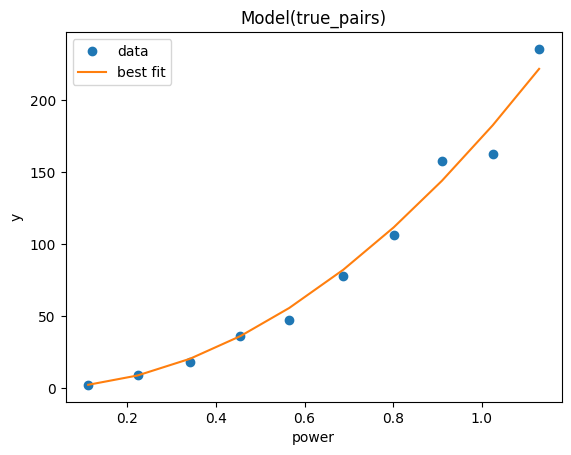

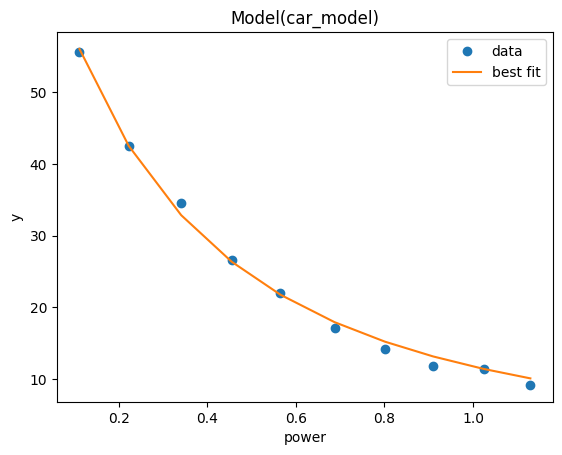

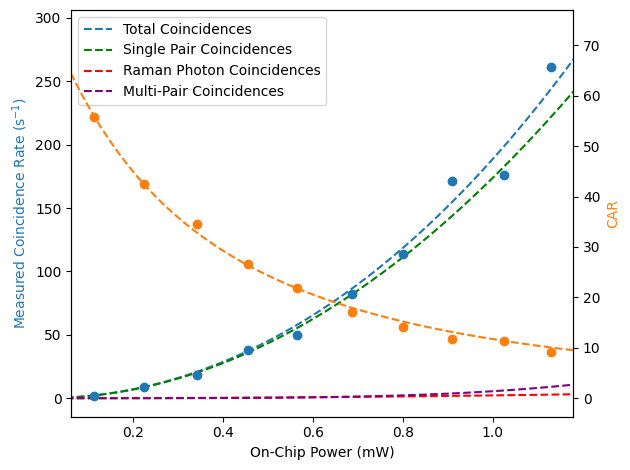

In [18]:
true_pairs_model = Model(true_pairs)
res_true_pair = true_pairs_model.fit(coincidences_bg_subtract,power=on_chip_power/1e3,c_p=3e7)
c_p = res_true_pair.params['c_p'].value
print("TRUE PAIR RATE FITTING")
print(res_true_pair.fit_report())
plt.figure()
res_true_pair.plot_fit()

car_fit = Model(car_model)
res_car = car_fit.fit(car,power=on_chip_power/1e3,c_r=1e7)
c_r = res_car.params['c_r'].value
print("CAR FITTING")
print(res_car.fit_report())
plt.figure()
res_car.plot_fit()

error = np.sqrt(coincidences) / integration_time
powers_for_fit = np.linspace(0, max(on_chip_power)+.1e3, 100)
color_coincidences = 'tab:blue'
color_car = 'tab:orange'

true_pairs_model = true_pairs(powers_for_fit/1e3,c_p)
raman_raman_model = raman_raman(powers_for_fit/1e3)
uncorrelated_pairs_model = uncorrelated_pairs(powers_for_fit/1e3)
pair_raman_model = pair_raman(powers_for_fit/1e3)
total_coinc_model = true_pairs_model+raman_raman_model+uncorrelated_pairs_model+pair_raman_model

eff_correction = 1#res_on_chip.eval(x=powers_for_fit/1e3)[-1]/total_coinc_model[-1]

fig, ax = plt.subplots()
ax_r = ax.twinx()
ax.errorbar(on_chip_power/1e3, coincidence_rate, yerr=error,
            capsize=3, marker='o', linestyle='', color=color_coincidences)
#ax.plot(powers_for_fit/1e3, res_on_chip.eval(x=powers_for_fit/1e3),
#        color=color_coincidences, ls='--')

ax.plot(powers_for_fit/1e3,total_coinc_model*eff_correction,color=color_coincidences,ls='--',label='Total Coincidences')
ax.plot(powers_for_fit/1e3,true_pairs_model*eff_correction,color='green',ls='--',label='Single Pair Coincidences')
ax.plot(powers_for_fit/1e3,raman_raman_model*eff_correction,color='red',ls='--',label = 'Raman Photon Coincidences')
ax.plot(powers_for_fit/1e3,uncorrelated_pairs_model*eff_correction,color='purple',ls='--',label = 'Multi-Pair Coincidences')
ax.legend()


ax_r.plot(on_chip_power/1e3, car,
          color=color_car, marker='o', ls='')
ax_r.plot(powers_for_fit/1e3,car_model(powers_for_fit/1e3,c_r),color=color_car,ls='--')
plt.xlim(min(on_chip_power)/1e3-.05,max(on_chip_power)/1e3+.05)

#ax_r.plot(powers_for_fit/1e3,total_coinc_model/bg_model(powers_for_fit/1e3,res_dual_opt['x'][0],res_dual_opt['x'][1],eff_test)-1.)


ax.set_xlabel(r'On-Chip Power (mW)')
ax.set_ylabel(r'Measured Coincidence Rate (s$^{-1}$)', color=color_coincidences)
ax_r.set_ylabel('CAR', color=color_car)

fig.tight_layout()
fig.show()

print(uncorrelated_pairs_model[-1]/raman_raman_model[-1])
print(c_p*(2.**2)/(c_r*2.))

## Final Plotting

In [48]:
# matplotlib general (and font)
mpl.rcParams.update({'font.sans-serif': 'Arial',
                     'font.size': 7})
figsize = (4, 3)
dpi = 300

# colors
color_source = '#7570b3'
color_source_2 = 'darkgray'

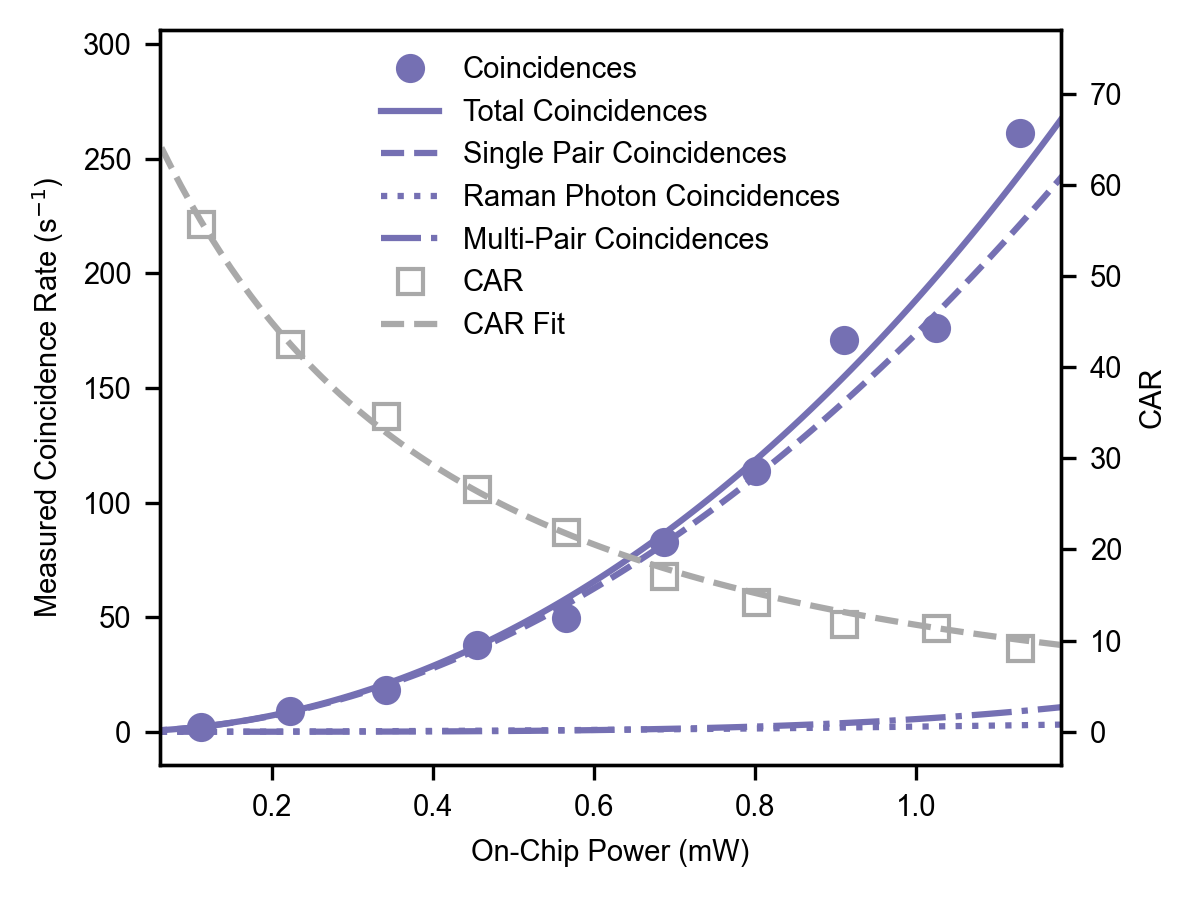

In [51]:
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
ax_r = ax.twinx()

# lns_coinc = ax.errorbar(on_chip_power/1e3, coincidence_rate, yerr=error,
#             capsize=3, marker='o', linestyle='', color=color_source,
#             label='Measured Coincidences')
lns_coinc = ax.plot(on_chip_power/1e3, coincidence_rate,
            marker='o', linestyle='', color=color_source,
            label='Coincidences')

lns_tot = ax.plot(powers_for_fit/1e3, total_coinc_model*eff_correction,
        color=color_source, ls='-',
        label='Total Coincidences')
lns_sing = ax.plot(powers_for_fit/1e3, true_pairs_model*eff_correction,
        color=color_source, ls='--',
        label='Single Pair Coincidences')
lns_raman = ax.plot(powers_for_fit/1e3, raman_raman_model*eff_correction,
        color=color_source, ls=':',
        label='Raman Photon Coincidences')
lns_multi = ax.plot(powers_for_fit/1e3, uncorrelated_pairs_model*eff_correction,
        color=color_source, ls='-.',
        label='Multi-Pair Coincidences')

lns_car = ax_r.plot(on_chip_power/1e3, car,
          color=color_source_2, ls='', marker='s', markerfacecolor='none', markeredgewidth=1,
          label='CAR')
lns_carfit = ax_r.plot(powers_for_fit/1e3, car_model(powers_for_fit/1e3, c_r),
          color=color_source_2, ls='--',
          label='CAR Fit')

lns = lns_coinc + lns_tot + lns_sing + lns_raman + lns_multi + lns_car + lns_carfit
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, frameon=False, loc='upper center')

plt.xlim(min(on_chip_power)/1e3-.05,max(on_chip_power)/1e3+.05)
ax.set_xlabel(r'On-Chip Power (mW)')
ax.set_ylabel(r'Measured Coincidence Rate (s$^{-1}$)')
ax_r.set_ylabel('CAR')

fig.tight_layout()

In [52]:
fig.savefig('sup_raman_model.pdf')